In [2]:
%load_ext autoreload
%autoreload 2

import os

import numpy as np
import unyt as u

import dev
import richio


In [3]:
DATADIR = "/home/hey4/rich_tde/data/processed/SimpleTimeseries"

configs = {
    "1e4": {
        "Rstar": 0.47 * richio.units.lscale,
        "Mstar": 0.5 * richio.units.mscale,
        "Mbh": 1e4 * richio.units.mscale,
    },
    "1e5": {
        "Rstar": 0.47 * richio.units.lscale,
        "Mstar": 0.5 * richio.units.mscale,
        "Mbh": 1e5 * richio.units.mscale,
    },
    "1e6": {
        "Rstar": 1 * richio.units.lscale,
        "Mstar": 1 * richio.units.mscale,
        "Mbh": 1e6 * richio.units.mscale,
    },
}

for mode, cfg in configs.items():
    Rstar, Mstar, Mbh = cfg["Rstar"], cfg["Mstar"], cfg["Mbh"]
    r_p = Rstar * (Mbh / Mstar) ** (1 / 3)
    cfg["r_p"] = r_p
    cfg["tmin"] = (
        np.pi
        / np.sqrt(2)
        * (Rstar**3 / u.G / Mstar) ** (1 / 2)
        * (Mbh / Mstar) ** (1 / 2)
    )
    cfg["DATAFILE"] = os.path.join(DATADIR, f"Rdiss-t-{mode}-final.txt")


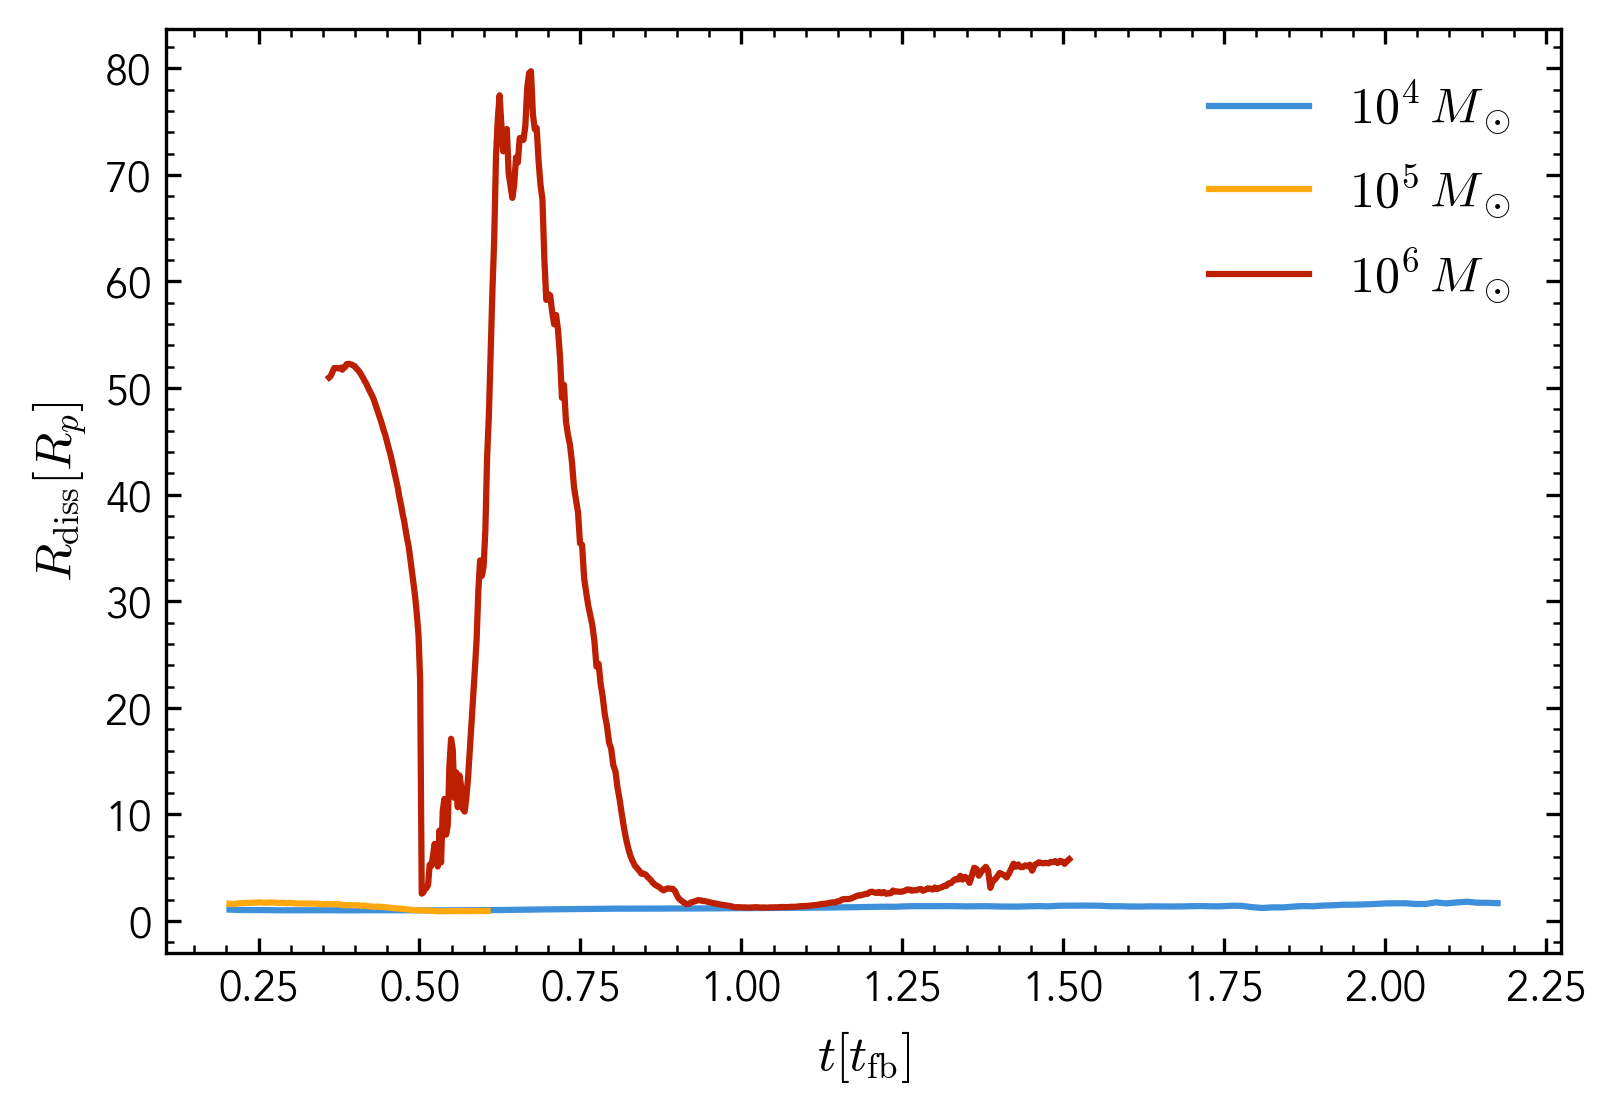

In [4]:
import matplotlib.pyplot as plt

reg = richio.units.registry

mode_colors = {"1e4": "C0", "1e5": "C1", "1e6": "C2"}
mode_labels = {
    "1e4": r"$10^4\,M_\odot$",
    "1e5": r"$10^5\,M_\odot$",
    "1e6": r"$10^6\,M_\odot$",
}

plt.figure(figsize=(6, 4), dpi=300)
for mode, cfg in configs.items():
    raw = np.loadtxt(cfg["DATAFILE"], delimiter="\t").T
    raw = raw[:, np.argsort(raw[1])]
    raw = raw[:, raw[2] >= 0.2]
    # if mode == "1e6":
    #     raw = raw[:, raw[2] >= 1.0]
    t_in_tmins = raw[2]
    Rdiss = raw[-1] * richio.units.lscale
    Rdiss /= cfg["r_p"]

    plt.plot(
        t_in_tmins, Rdiss, color=mode_colors[mode], linewidth=1.5, label=mode_labels[mode]
    )

plt.xlabel(r"$t[t_\mathrm{fb}]$")
plt.ylabel(r"$R_\mathrm{diss}[R_p]$")
# plt.yscale("log")
# plt.ylim(0, 1200)
plt.legend()

# plt.xlim(1, 2)
# plt.grid()
plt.show()


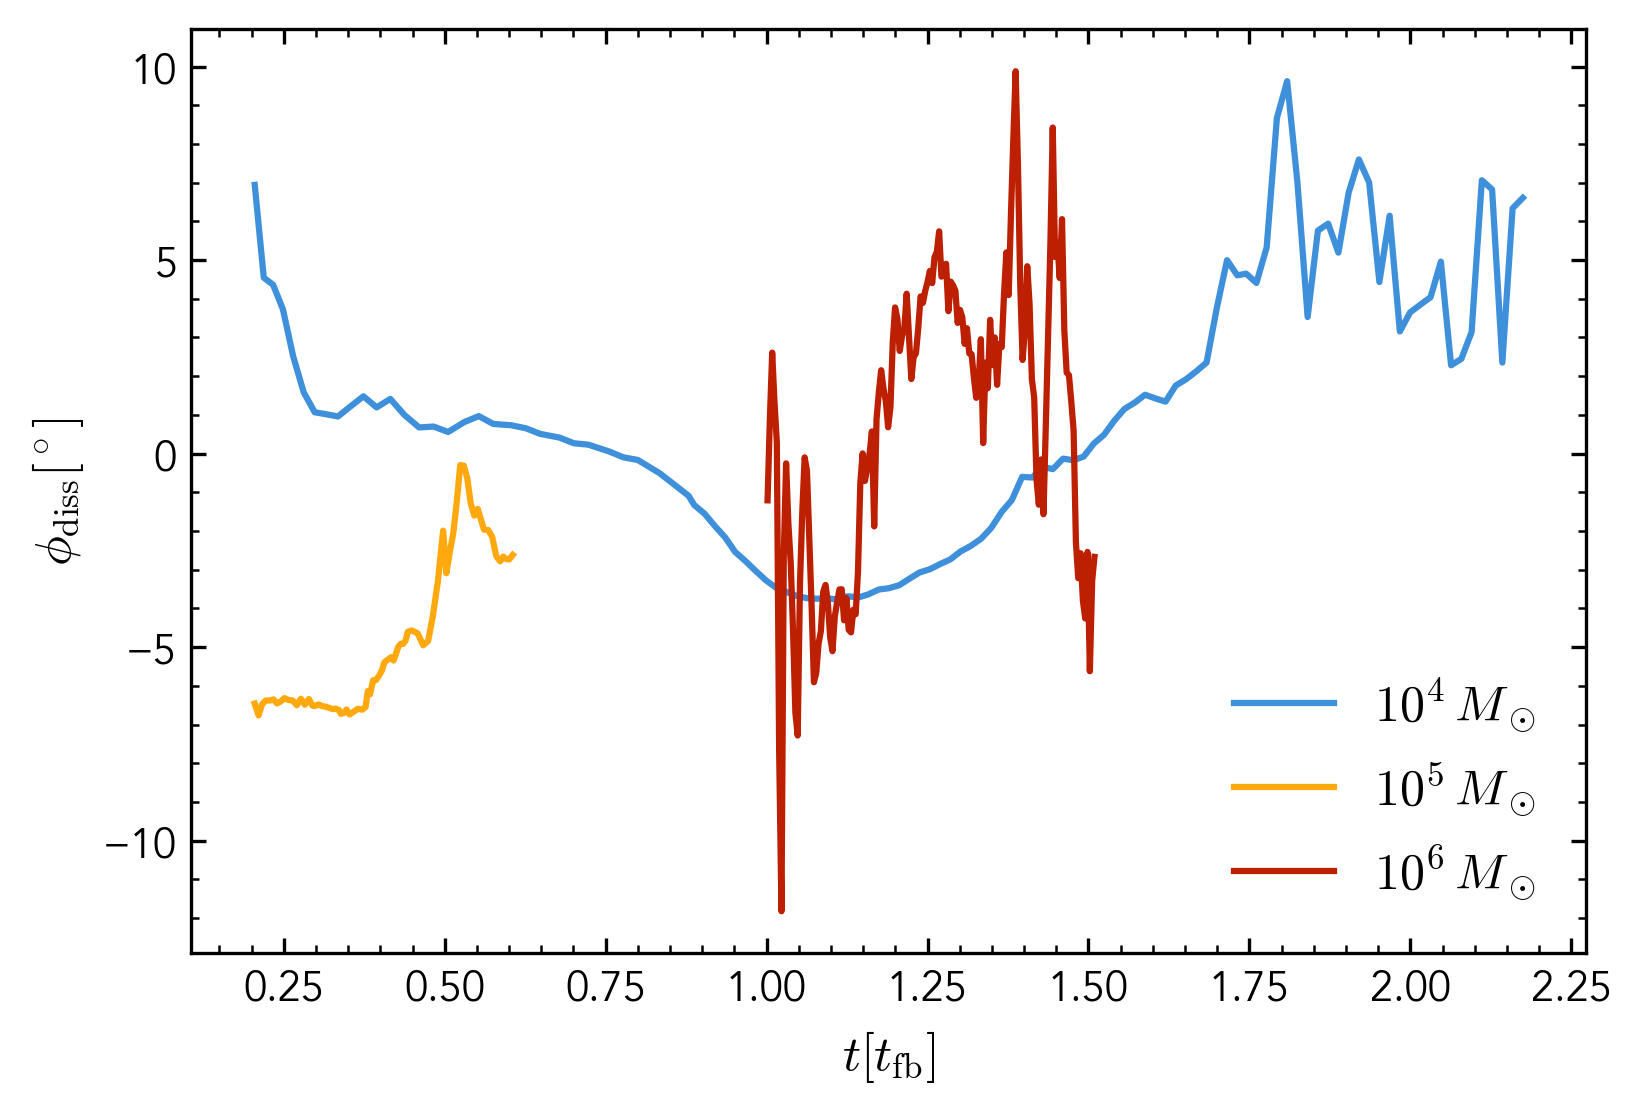

In [5]:
import matplotlib.pyplot as plt

reg = richio.units.registry

mode_colors = {"1e4": "C0", "1e5": "C1", "1e6": "C2"}
mode_labels = {
    "1e4": r"$10^4\,M_\odot$",
    "1e5": r"$10^5\,M_\odot$",
    "1e6": r"$10^6\,M_\odot$",
}

plt.figure(figsize=(6, 4), dpi=300)
for mode, cfg in configs.items():
    raw = np.loadtxt(cfg["DATAFILE"], delimiter="\t").T
    raw = raw[:, np.argsort(raw[1])]
    raw = raw[:, raw[2] >= 0.2]
    if mode == "1e6":
        raw = raw[:, raw[2] >= 1.0]
    t_in_tmins = raw[2]
    x_diss = raw[3] * richio.units.lscale
    y_diss = raw[4] * richio.units.lscale
    z_diss = raw[5] * richio.units.lscale
    phi_diss = np.arctan2(y_diss, x_diss)
    

    plt.plot(
        t_in_tmins,
        phi_diss * 90 / np.pi,
        color=mode_colors[mode],
        linewidth=1.5,
        label=mode_labels[mode],
    )

plt.xlabel(r"$t[t_\mathrm{fb}]$")
plt.ylabel(r"$\phi_\mathrm{diss}[^\circ]$")
# plt.yscale("log")
# plt.ylim(-90, 90)
plt.legend()

# plt.xlim(1, 2)
# plt.grid()
plt.show()


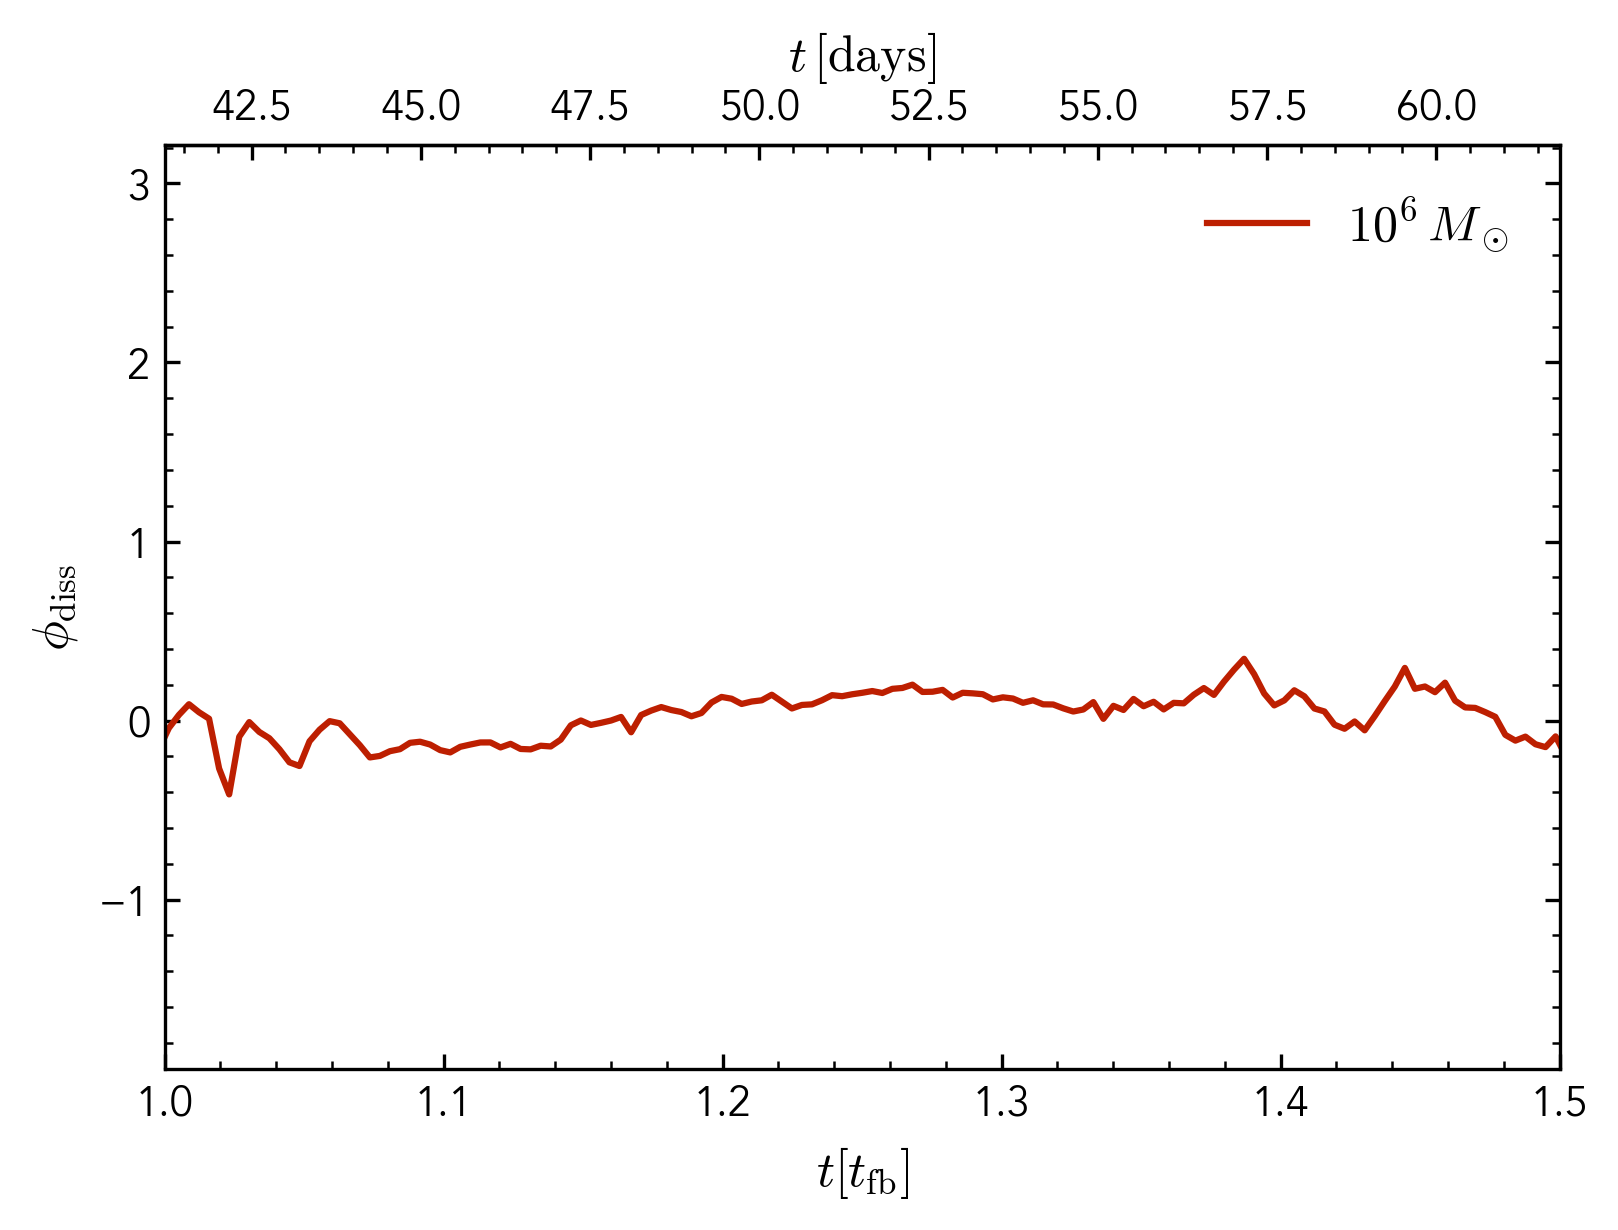

In [6]:
import matplotlib.pyplot as plt

reg = richio.units.registry

mode_colors = {"1e4": "C0", "1e5": "C1", "1e6": "C2"}
mode_labels = {
    "1e4": r"$10^4\,M_\odot$",
    "1e5": r"$10^5\,M_\odot$",
    "1e6": r"$10^6\,M_\odot$",
}

plt.figure(figsize=(6, 4), dpi=300)
mode = "1e6"
cfg = configs[mode]
raw = np.loadtxt(cfg["DATAFILE"], delimiter="\t").T
raw = raw[:, np.argsort(raw[1])]
raw = raw[:, raw[2] >= 0.1]
t_in_tmins = raw[2]
x_diss = raw[3] * richio.units.lscale
y_diss = raw[4] * richio.units.lscale
z_diss = raw[5] * richio.units.lscale
phi_diss = np.arctan2(y_diss, x_diss)

plt.plot(
    t_in_tmins,
    phi_diss,
    color=mode_colors[mode],
    linewidth=1.5,
    label=mode_labels[mode],
)

plt.xlabel(r"$t[t_\mathrm{fb}]$")
plt.ylabel(r"$\phi_\mathrm{diss}$")
# plt.yscale("log")
# plt.ylim(-90, 90)
plt.legend()

plt.xlim(1, 1.5)
# plt.grid()

plt.gca().tick_params(which="both", top=False)
tmin_days = float(cfg["tmin"].to("day"))
secax = plt.gca().secondary_xaxis("top", functions=(lambda x, m=tmin_days: x * m, lambda x, m=tmin_days: x / m))
secax.set_xlabel(r"$t\,[\mathrm{days}]$")

plt.show()
